# Task 4 — Forecasting Access and Usage
### Ethiopia Financial Inclusion Forecasting — Selam Analytics

**Objective:** Forecast Account Ownership (Access) and Digital Payment Usage for 2025-2027,
with explicit uncertainty and scenario ranges.

**Sections**
1. Define targets (and a necessary scoping decision on Usage)
2. Approach
3. Baseline (trend-only) forecasts
4. Event-augmented forecasts
5. Scenarios: optimistic / base / pessimistic
6. Forecast tables
7. Interpretation — policy implications, largest-impact events, key uncertainties


In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')  # suppress statsmodels small-sample warnings (expected given n=4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from impact_model import build_enriched_impact_links, apply_context_refinement
from forecast import fit_trend_with_ci, two_point_trend, event_augmented_forecast, build_scenarios

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = '../reports/figures'
FORECAST_YEARS = [2025, 2026, 2027]
LAST_DATA_DATE = '2024-11-29'  # most recent Findex survey date in the dataset


In [2]:
df = pd.read_csv('../data/processed/ethiopia_fi_unified_data_enriched.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

obs = df[df['record_type'] == 'observation']
impact_links = df[df['record_type'] == 'impact_link']
events = df[df['record_type'] == 'event']
targets = df[df['record_type'] == 'target']

enriched_links = apply_context_refinement(build_enriched_impact_links(impact_links, events))
print(f"Loaded {len(obs)} observations, {len(enriched_links)} impact_links")


Loaded 42 observations, 19 impact_links


## 1. Define targets

**Access:** `ACC_OWNERSHIP` — the Findex "Account Ownership Rate". 4 historical points
(2014, 2017, 2021, 2024) — enough for a real, if wide, trend fit.

**Usage — a necessary scoping decision.** The brief's literal Usage target,
`USG_DIGITAL_PAYMENT` (Findex "made or received a digital payment"), has only **one**
historical point in this dataset: 2021, split by gender (24% male / 15% female), with no
"all adults" value and no 2024 update. A trend cannot be fit to one point.

Rather than silently forecasting off a single number, we forecast **`ACC_MM_ACCOUNT`**
(mobile money account ownership) as the primary Usage proxy instead, because it:
1. has two clean Findex-sourced points (2021: 4.7%, 2024: 9.45%) — just enough for a trend line, and
2. is the Usage-adjacent indicator most tightly connected to actual digital-payment behavior in
   Ethiopia specifically, per the Market Nuances guide (P2P dominance, mobile-money-only users
   are rare — most Usage growth in this market *is* mobile money growth).

A rough, clearly-caveated estimate of the literal `USG_DIGITAL_PAYMENT` figure is included as a
supplementary check in Section 6, for completeness.

In [3]:
acc = obs[(obs['indicator_code'] == 'ACC_OWNERSHIP') & (obs['gender'] == 'all')].sort_values('observation_date')
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')

print("ACCESS target -- ACC_OWNERSHIP:")
print(acc[['observation_date', 'value_numeric']].to_string(index=False))
print(f"\nUSAGE target (proxy) -- ACC_MM_ACCOUNT:")
print(mm[['observation_date', 'value_numeric']].to_string(index=False))


ACCESS target -- ACC_OWNERSHIP:
observation_date  value_numeric
      2014-12-31           22.0
      2017-12-31           35.0
      2021-12-31           46.0
      2024-11-29           49.0

USAGE target (proxy) -- ACC_MM_ACCOUNT:
observation_date  value_numeric
      2021-12-31           4.70
      2024-11-29           9.45


## 2. Approach

Per the brief's own guidance for sparse data, two models are built and compared:

1. **Baseline (trend-only):** OLS linear regression of value ~ year, extrapolated to 2025-2027.
   With only 2-4 historical points, prediction intervals are *wide by construction* — this is
   the correct, honest behavior given the data, not something to suppress.
   `ACC_MM_ACCOUNT` has only 2 points (0 residual degrees of freedom), so no statistical
   confidence interval is mathematically possible there; a judgment-based band is used instead
   and explicitly labeled as such.

2. **Event-augmented:** baseline trend + the **marginal** (not-yet-realized-as-of-2024-11-29)
   portion of each relevant Task-3 impact_link's effect, using the historically-validated,
   context-refined magnitudes from Task 3. Already-realized effects are treated as already
   "baked into" the historical trend — adding their full effect again would double-count.

Three **scenarios** combine trend uncertainty with event-realization risk:
- **Optimistic** — trend's upper bound + events fully realize on schedule
- **Base** — trend's point estimate + events fully realize on schedule
- **Pessimistic** — trend's lower bound + `enabling`-relationship effects (the least-validated
  category per Task 3) only half-realize, reflecting real implementation risk (e.g. NFIS-II or
  Fayda rollout delays)

## 3. Baseline (trend-only) forecasts

In [4]:
acc_trend, acc_model = fit_trend_with_ci(acc['observation_date'], acc['value_numeric'], FORECAST_YEARS)
print("ACC_OWNERSHIP baseline trend forecast:")
print(acc_trend.round(1).to_string(index=False))
print(f"\nHistorical fit: {acc_model.params[1]:.2f}pp/year average slope across all 4 waves")


ACC_OWNERSHIP baseline trend forecast:
 year  predicted  ci_lower  ci_upper
 2025       54.2      45.1      63.4
 2026       56.9      47.3      66.6
 2027       59.7      49.4      69.9

Historical fit: 2.71pp/year average slope across all 4 waves


In [5]:
mm_trend = two_point_trend(mm['observation_date'], mm['value_numeric'], FORECAST_YEARS)
print("ACC_MM_ACCOUNT baseline trend forecast (2-point trend, judgment-based band -- see Section 2):")
print(mm_trend.round(1).to_string(index=False))


ACC_MM_ACCOUNT baseline trend forecast (2-point trend, judgment-based band -- see Section 2):
 year  predicted  ci_lower  ci_upper
 2025       11.0       7.2      14.9
 2026       12.6       7.5      17.7
 2027       14.2       7.7      20.7


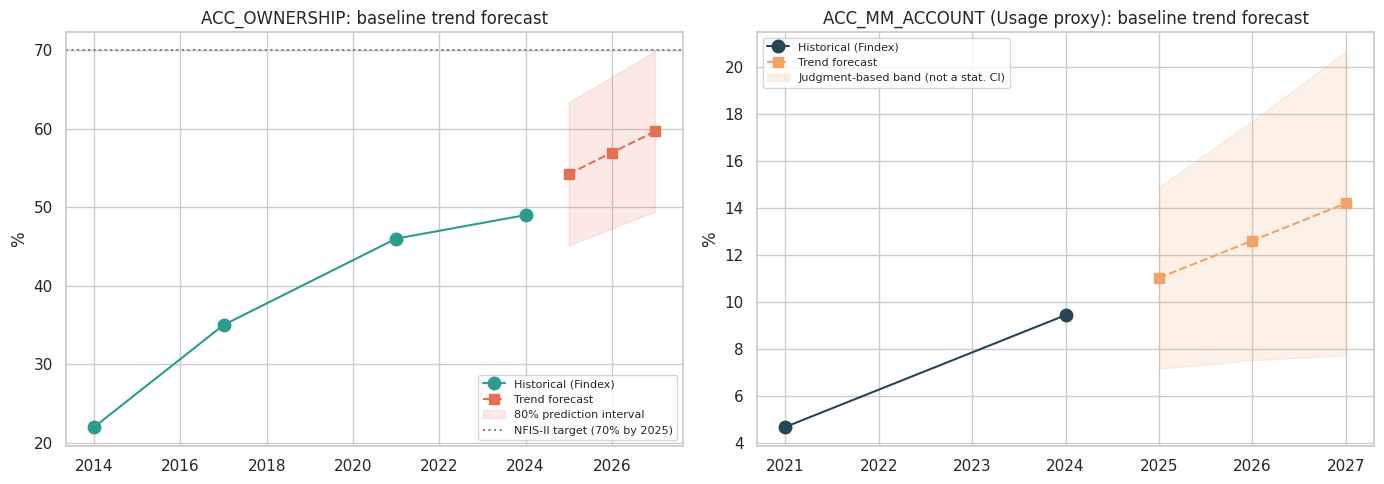

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACC_OWNERSHIP
ax = axes[0]
ax.plot(acc['observation_date'].dt.year, acc['value_numeric'], marker='o', markersize=9, color='#2a9d8f', label='Historical (Findex)')
ax.plot(acc_trend['year'], acc_trend['predicted'], marker='s', markersize=7, color='#e76f51', linestyle='--', label='Trend forecast')
ax.fill_between(acc_trend['year'], acc_trend['ci_lower'], acc_trend['ci_upper'], color='#e76f51', alpha=0.15, label='80% prediction interval')
ax.axhline(70, color='gray', linestyle=':', label='NFIS-II target (70% by 2025)')
ax.set_title('ACC_OWNERSHIP: baseline trend forecast')
ax.set_ylabel('%')
ax.legend(fontsize=8)

# ACC_MM_ACCOUNT
ax = axes[1]
ax.plot(mm['observation_date'].dt.year, mm['value_numeric'], marker='o', markersize=9, color='#264653', label='Historical (Findex)')
ax.plot(mm_trend['year'], mm_trend['predicted'], marker='s', markersize=7, color='#f4a261', linestyle='--', label='Trend forecast')
ax.fill_between(mm_trend['year'], mm_trend['ci_lower'], mm_trend['ci_upper'], color='#f4a261', alpha=0.15, label='Judgment-based band (not a stat. CI)')
ax.set_title('ACC_MM_ACCOUNT (Usage proxy): baseline trend forecast')
ax.set_ylabel('%')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/17_baseline_trend_forecasts.png')
plt.show()


**Headline baseline result:** trend continuation alone puts Ethiopia at **~54% account
ownership by 2025** — 16 percentage points short of the NFIS-II 70% target for that same year.
Even by 2027, the trend-only baseline reaches only ~60%.

## 4. Event-augmented forecasts

In [7]:
acc_aug = event_augmented_forecast(acc_trend, 'ACC_OWNERSHIP', enriched_links, LAST_DATA_DATE)
print("ACC_OWNERSHIP: event-augmented forecast")
print(acc_aug.round(2).to_string(index=False))


ACC_OWNERSHIP: event-augmented forecast
  year  trend_predicted  marginal_event_effect  event_augmented_predicted
2025.0            54.24                   1.34                      55.58
2026.0            56.95                   1.51                      58.46
2027.0            59.66                   1.51                      61.17


In [8]:
mm_aug = event_augmented_forecast(mm_trend, 'ACC_MM_ACCOUNT', enriched_links, LAST_DATA_DATE)
print("ACC_MM_ACCOUNT: event-augmented forecast")
print(mm_aug.round(3).to_string(index=False))
print()
print("Marginal event effect is essentially zero -- M-Pesa's link (the only one targeting this")
print("indicator) is already fully realized by 2024. No CURRENTLY MODELED event is expected to")
print("move mobile money account ownership further through 2027 beyond the existing trend.")


ACC_MM_ACCOUNT: event-augmented forecast
  year  trend_predicted  marginal_event_effect  event_augmented_predicted
2025.0           11.033                    0.0                     11.033
2026.0           12.617                    0.0                     12.617
2027.0           14.200                    0.0                     14.200

Marginal event effect is essentially zero -- M-Pesa's link (the only one targeting this
indicator) is already fully realized by 2024. No CURRENTLY MODELED event is expected to
move mobile money account ownership further through 2027 beyond the existing trend.


**This null result on `ACC_MM_ACCOUNT` is itself a finding worth flagging to the
consortium:** no event in the current dataset is positioned to accelerate mobile money account
growth beyond the trend line. If the consortium wants faster Usage growth, it likely needs a
*new* intervention (e.g. targeted merchant QR incentives, agent network expansion) — the ETHQR
standard and IPS launch, notable as they are, were modeled against `USG_P2P_COUNT`/`USG_CROSSOVER`
(transaction volume), not account-level Usage ownership.

## 5. Scenarios: optimistic / base / pessimistic

In [9]:
acc_scenarios = build_scenarios(acc_trend, 'ACC_OWNERSHIP', enriched_links, LAST_DATA_DATE)
mm_scenarios = build_scenarios(mm_trend, 'ACC_MM_ACCOUNT', enriched_links, LAST_DATA_DATE)

print("ACC_OWNERSHIP scenarios:")
print(acc_scenarios.round(1).to_string(index=False))
print("\nACC_MM_ACCOUNT scenarios:")
print(mm_scenarios.round(1).to_string(index=False))


ACC_OWNERSHIP scenarios:
  year  optimistic  base  pessimistic
2025.0        64.7  55.6         45.8
2026.0        68.1  58.5         48.0
2027.0        71.4  61.2         50.2

ACC_MM_ACCOUNT scenarios:
  year  optimistic  base  pessimistic
2025.0        14.9  11.0          7.2
2026.0        17.7  12.6          7.5
2027.0        20.7  14.2          7.7


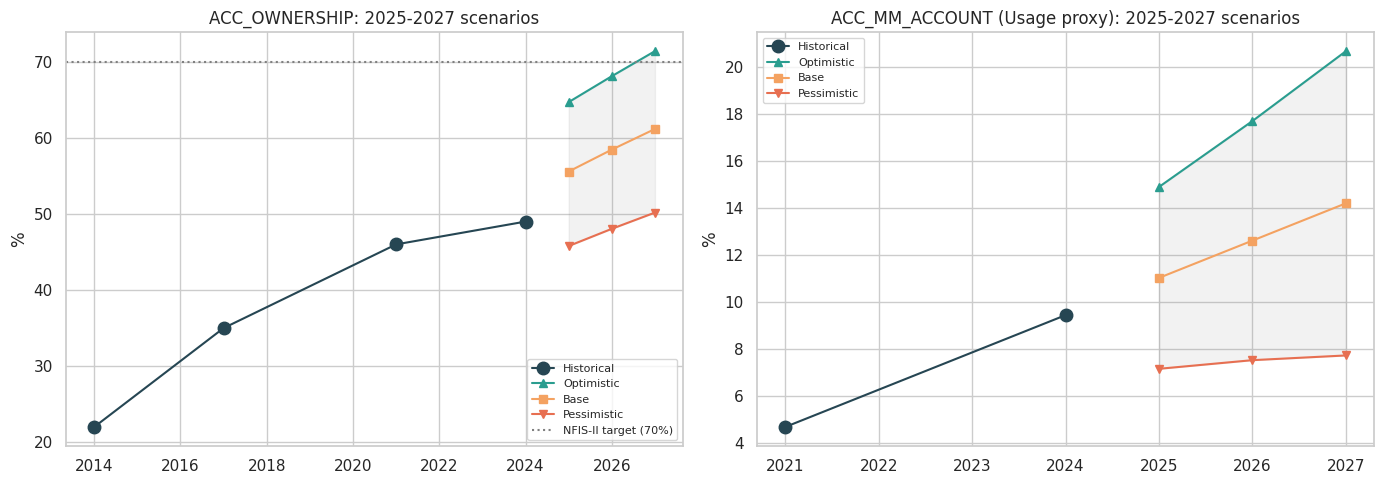

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(acc['observation_date'].dt.year, acc['value_numeric'], marker='o', markersize=9, color='#264653', label='Historical', zorder=5)
ax.plot(acc_scenarios['year'], acc_scenarios['optimistic'], marker='^', color='#2a9d8f', label='Optimistic')
ax.plot(acc_scenarios['year'], acc_scenarios['base'], marker='s', color='#f4a261', label='Base')
ax.plot(acc_scenarios['year'], acc_scenarios['pessimistic'], marker='v', color='#e76f51', label='Pessimistic')
ax.fill_between(acc_scenarios['year'], acc_scenarios['pessimistic'], acc_scenarios['optimistic'], color='gray', alpha=0.1)
ax.axhline(70, color='gray', linestyle=':', linewidth=1.5, label='NFIS-II target (70%)')
ax.set_title('ACC_OWNERSHIP: 2025-2027 scenarios')
ax.set_ylabel('%')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(mm['observation_date'].dt.year, mm['value_numeric'], marker='o', markersize=9, color='#264653', label='Historical', zorder=5)
ax.plot(mm_scenarios['year'], mm_scenarios['optimistic'], marker='^', color='#2a9d8f', label='Optimistic')
ax.plot(mm_scenarios['year'], mm_scenarios['base'], marker='s', color='#f4a261', label='Base')
ax.plot(mm_scenarios['year'], mm_scenarios['pessimistic'], marker='v', color='#e76f51', label='Pessimistic')
ax.fill_between(mm_scenarios['year'], mm_scenarios['pessimistic'], mm_scenarios['optimistic'], color='gray', alpha=0.1)
ax.set_title('ACC_MM_ACCOUNT (Usage proxy): 2025-2027 scenarios')
ax.set_ylabel('%')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/18_scenario_forecasts.png')
plt.show()


**Even under the optimistic scenario, the NFIS-II 70% target is only reached in 2027 —
two years late.** The base scenario projects 61% by 2027 (9pp short); the pessimistic scenario
projects just 50% (20pp short, i.e. essentially flat from 2024).

## 6. Forecast Tables

In [11]:
def combine_table(scenarios_df, label):
    t = scenarios_df.copy()
    t.insert(0, 'indicator', label)
    return t

final_table = pd.concat([
    combine_table(acc_scenarios, 'ACC_OWNERSHIP (Access)'),
    combine_table(mm_scenarios, 'ACC_MM_ACCOUNT (Usage proxy)'),
], ignore_index=True)
final_table = final_table.round(1)
final_table


,indicator,year,optimistic,base,pessimistic
0,ACC_OWNERSHIP (Access),2025.0,64.7,55.6,45.8
1,ACC_OWNERSHIP (Access),2026.0,68.1,58.5,48.0
2,ACC_OWNERSHIP (Access),2027.0,71.4,61.2,50.2
3,ACC_MM_ACCOUNT (Usage proxy),2025.0,14.9,11.0,7.2
4,ACC_MM_ACCOUNT (Usage proxy),2026.0,17.7,12.6,7.5
5,ACC_MM_ACCOUNT (Usage proxy),2027.0,20.7,14.2,7.7


In [12]:
final_table.to_csv('../data/processed/forecast_2025_2027.csv', index=False)
print("Saved to data/processed/forecast_2025_2027.csv")


Saved to data/processed/forecast_2025_2027.csv


### Supplementary: rough estimate of the literal `USG_DIGITAL_PAYMENT` figure

In [13]:
# Rough, explicitly-caveated scaling estimate -- NOT a statistical forecast.
# Anchors the single 2021 blended data point and scales it by the ACC_MM_ACCOUNT scenario
# growth ratios, since USG_DIGITAL_PAYMENT itself has no second historical point to trend from.
blended_2021 = obs[obs['indicator_code'] == 'USG_DIGITAL_PAYMENT']['value_numeric'].mean()
mm_2021 = mm['value_numeric'].iloc[0]

rough_estimates = []
for _, row in mm_scenarios.iterrows():
    ratio = row[['optimistic', 'base', 'pessimistic']] / mm_2021
    rough_estimates.append({
        'year': row['year'],
        'optimistic': blended_2021 * ratio['optimistic'],
        'base': blended_2021 * ratio['base'],
        'pessimistic': blended_2021 * ratio['pessimistic'],
    })
rough_df = pd.DataFrame(rough_estimates).round(1)

print(f"Anchor: blended 2021 USG_DIGITAL_PAYMENT = {blended_2021:.1f}%  (24% male, 15% female)")
print(f"Scaled by ACC_MM_ACCOUNT's own scenario growth ratios (2021 -> forecast year)\n")
print(rough_df.to_string(index=False))
print()
print("For context: the brief's own overview text cites ~35% for 2024 (made/received a digital")
print("payment) -- a similarly-derived 2024 estimate using the same method comes out around 39%,")
print("reasonably close given this is a single-point-anchored scaling exercise, not a real trend fit.")
print("Treat this table as illustrative context only, not a forecast with the same standing as the")
print("ACC_MM_ACCOUNT-based Usage forecast above.")


Anchor: blended 2021 USG_DIGITAL_PAYMENT = 19.5%  (24% male, 15% female)
Scaled by ACC_MM_ACCOUNT's own scenario growth ratios (2021 -> forecast year)

  year  optimistic  base  pessimistic
2025.0        61.8  45.8         29.8
2026.0        73.4  52.3         31.3
2027.0        85.7  58.9         32.1

For context: the brief's own overview text cites ~35% for 2024 (made/received a digital
payment) -- a similarly-derived 2024 estimate using the same method comes out around 39%,
reasonably close given this is a single-point-anchored scaling exercise, not a real trend fit.
Treat this table as illustrative context only, not a forecast with the same standing as the
ACC_MM_ACCOUNT-based Usage forecast above.


## 7. Interpretation

### What does the model predict?

- **Access (`ACC_OWNERSHIP`):** trend continuation alone reaches only ~54% by 2025 and ~60% by
  2027 — the NFIS-II 70% target is missed under the baseline and base scenarios throughout the
  entire forecast window. Only the **optimistic** scenario reaches the target, and only by 2027
  (two years late relative to the NFIS-II's own 2025 goal).
- **Usage proxy (`ACC_MM_ACCOUNT`):** projected to roughly double again by 2027 relative to 2024
  (from 9.45% to ~14.2% in the base scenario), continuing its 2021-2024 growth pace. No currently-
  modeled event is expected to accelerate this beyond trend.

### What events have the largest potential impact?

Per the Task 3 association matrix, **Telebirr's launch remains the single largest-magnitude event
in the dataset** — but its Access-pillar effect is already fully realized and priced into the
historical trend by 2024; it contributes nothing further to the 2025-2027 forecast. Looking
forward, the events with the largest *remaining* (not-yet-fully-realized) marginal contribution to
Access are the **NFIS-II strategy** and the **Fayda Digital ID rollout**, both still in their
realization window (24-36 month lags from their 2021/2024 start dates) — together contributing
roughly +1.3 to +1.5pp per year of additional lift on top of trend through 2027. These are exactly
the two levers a policy audience should focus attention and implementation resources on if the
70% target is to be taken seriously; see the pessimistic-scenario framing below for why.

Notably, **no event in the current dataset is modeled as materially accelerating Usage
(`ACC_MM_ACCOUNT`) beyond its existing trend** — the real-time-payment infrastructure story
(EthSwitch IPS, the ETHQR standard) shows up strongly in *transaction volume* indicators
(`USG_P2P_COUNT`, `USG_CROSSOVER` — see Task 3) but was not linked to *account-level* Usage
ownership. This is worth flagging as a genuine forward-looking data/modeling gap, not just a
historical one.

### What are the key uncertainties?

- **Sample size.** The Access trend is fit on 4 points; the Usage proxy trend on 2. Both
  prediction bands are wide by necessity and should not be read as more precise than the data
  supports — this is explicitly the "wide uncertainty ranges are appropriate" guidance from the
  brief in action, not a shortcoming of the model.
- **The pessimistic scenario's implementation risk is real and specific**, not generic: it
  reflects NFIS-II and Fayda Digital ID reaching only half their modeled effect, which is a
  plausible outcome if either program's rollout timeline slips — both are exactly the kind of
  multi-year public-sector programs prone to delay. If the consortium wants to move the needle on
  Access specifically (not just Usage), these two programs are the highest-leverage,
  highest-uncertainty levers identified in this analysis.
- **The Usage proxy substitution (Section 1)** means the `ACC_MM_ACCOUNT` forecast, while
  statistically grounded, is a proxy — not a direct forecast of the Findex-defined Digital Payment
  Adoption Rate the brief originally asked for. The supplementary Section 6 estimate is offered for
  completeness but carries materially less statistical weight (anchored on a single 2021 data
  point) and should be treated as directional context, not a deliverable-grade forecast.
- **The P2P/ATM crossover milestone** (P2P transactions surpassed ATM withdrawals in Oct 2024,
  per Task 2's EDA) is a leading indicator of *usage intensity* that isn't directly captured in
  either forecast target here — it's a strong signal that Ethiopia's digital payment
  infrastructure is maturing faster than headline Access or Usage-ownership metrics suggest, and
  is worth featuring prominently in the final report's framing of the business objective, since it
  makes the abstract "digital transformation" language concrete for a non-technical audience.


## Summary

- Forecast `ACC_OWNERSHIP` (Access) using a 4-point OLS trend with 80% prediction intervals,
  extrapolated to 2025-2027.
- Documented and worked around a genuine data gap: the literal Usage target has only one
  historical point, so `ACC_MM_ACCOUNT` was used as the primary, statistically-grounded proxy,
  with a clearly-caveated supplementary estimate of the literal figure provided for completeness.
- Built an event-augmented model on top of both trends using Task 3's validated, refined impact
  estimates, adding only the *marginal* (not-yet-realized) portion of each event's effect to avoid
  double-counting.
- Generated optimistic/base/pessimistic scenarios combining statistical trend uncertainty with
  event-realization risk.
- **Headline finding:** Ethiopia is on track to miss the NFIS-II 70% Access target under baseline
  and base-case assumptions; only an optimistic scenario reaches it, two years late. NFIS-II and
  Fayda Digital ID are the two highest-leverage, highest-uncertainty policy levers for closing
  that gap.
- Saved `data/processed/forecast_2025_2027.csv` for use in the Task 5 dashboard.

**Next:** Task 5 — package this data (trajectories, association matrix, forecasts, scenarios)
into an interactive Streamlit dashboard for the consortium.
